In [132]:
import numpy as np
import pandas as pd

dataset = pd.read_csv('steam_games.csv')
print(dataset.shape)

ValueError: Key backend: 'module://ipympl.backend_nbagg' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template', 'inline']

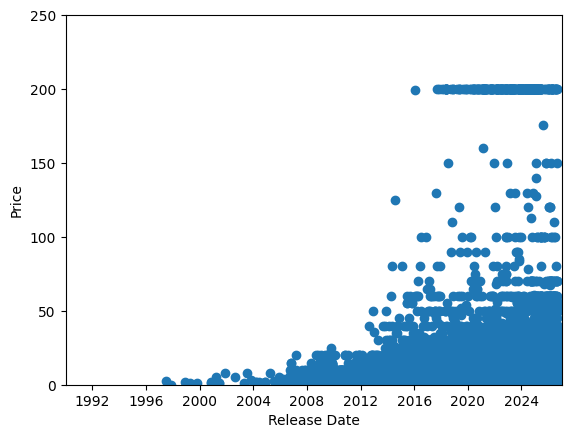

In [122]:
import matplotlib.pyplot as plt
dataset['release_date'] = pd.to_datetime(dataset['release_date'], errors='coerce')
dataset['price'] = pd.to_numeric(dataset['price'], errors='coerce')
plot_data = dataset.dropna(subset=['release_date', 'price'])
plt.scatter(plot_data['release_date'], plot_data['price'])
plt.xlabel('Release Date')
plt.ylabel('Price')
plt.ylim(0, 250)
plt.xlim(pd.to_datetime('1990-01-01'), pd.to_datetime('2027-01-01'))
plt.show()

## Linear Regression Model attempting to predict price from release date

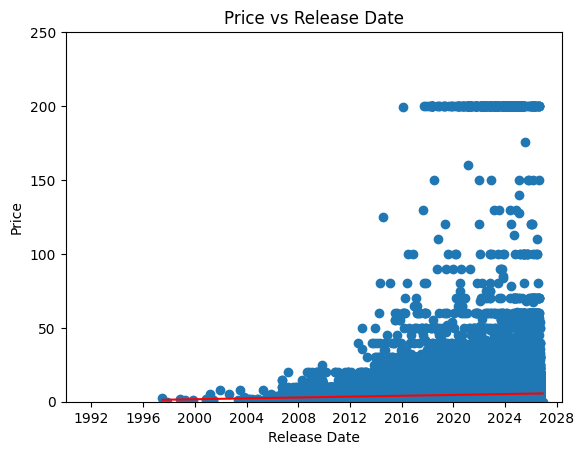

In [123]:
from sklearn.linear_model import LinearRegression

model = LinearRegression(fit_intercept=True)

regression_data = plot_data[['release_date', 'price']].dropna().copy()
# Convert release_date to days since the earliest release date
regression_data['days_since_earliest'] = (
    regression_data['release_date'] - regression_data['release_date'].min()
).dt.days

x = regression_data['days_since_earliest'].to_numpy()
y = regression_data['price'].to_numpy()

model.fit(x[:, np.newaxis], y)

xfit = np.linspace(x.min(), x.max(), 250)
yfit = model.predict(xfit[:, np.newaxis])

# Convert xfit back to datetime for plotting
datefit = regression_data['release_date'].min() + pd.to_timedelta(xfit, unit='D')

plt.scatter(regression_data['release_date'], regression_data['price'])
plt.plot(datefit, yfit, color='red')

r1 = model.score(x[:, np.newaxis], y)

plt.xlabel('Release Date')
plt.ylabel('Price')
plt.title('Price vs Release Date')
plt.ylim(0, 250)
plt.xlim(left=pd.to_datetime('1990-01-01'))
plt.show()

As can be seen from the plot, the linear regression model draws a line very closely following the bottom of the chart. This is due to the fact that the vast majority of games are priced close to \\$0 USD, and the model is attempting to minimize the error across all data points.

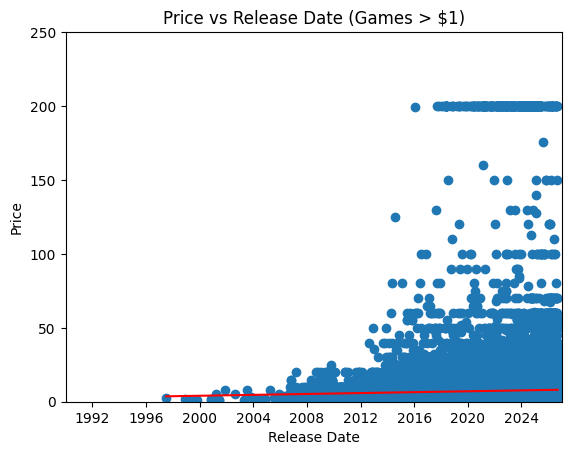

In [124]:
regression_data = plot_data[
    (plot_data['price'] > 1)
].dropna(subset=['release_date', 'price']).copy()

regression_data['days_since_earliest'] = (
    regression_data['release_date']
    - regression_data['release_date'].min()
).dt.days

x2 = regression_data['days_since_earliest'].to_numpy()
y2 = regression_data['price'].to_numpy()

model2 = LinearRegression(fit_intercept=True)
model2.fit(x2[:, np.newaxis], y2)

xfit = np.linspace(x2.min(), x2.max(), 100)
yfit = model2.predict(xfit[:, np.newaxis])

datefit2 = (
    regression_data['release_date'].min()
    + pd.to_timedelta(xfit, unit='D')
)

r2 = model2.score(x2[:, np.newaxis], y2)

plt.scatter(regression_data['release_date'], regression_data['price'],)
plt.plot(datefit2, yfit, color='red')
plt.xlabel('Release Date')
plt.ylabel('Price')
plt.title('Price vs Release Date (Games > $1)')
plt.ylim(0, 250)
plt.xlim(pd.to_datetime('1990-01-01'), pd.to_datetime('2027-01-01'))
plt.show()

As can be seen from this plot, removing the games priced at \\$1 USD or less did not significantly change the linear regression model. The model still draws a line closely following the bottom of the chart, indicating that the majority of games are still priced closer to \\$0 USD. In fact, the model ends up scoring worse, as indicated by the R² value below.

In [125]:
print("R²:     ", r1)
print("R²(>1$):", r2)

R²:      0.0015811528854702273
R²(>1$): 0.0012814054888949933


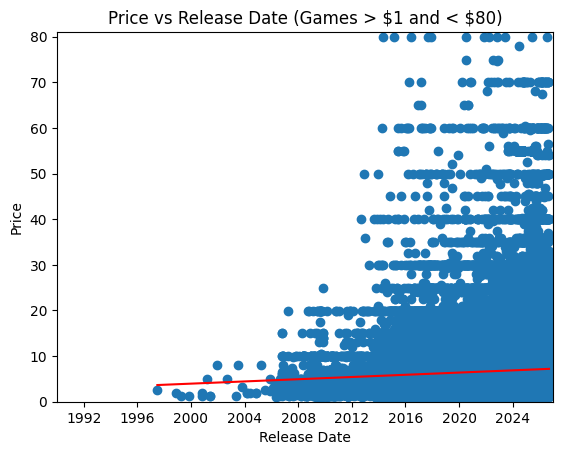

In [126]:
regression_data = plot_data[
    ((plot_data['price'] > 1) & (plot_data['price'] < 80))
].dropna(subset=['release_date', 'price']).copy()

regression_data['days_since_earliest'] = (
    regression_data['release_date']
    - regression_data['release_date'].min()
).dt.days

x3 = regression_data['days_since_earliest'].to_numpy()
y3 = regression_data['price'].to_numpy()

model3 = LinearRegression(fit_intercept=True)
model3.fit(x3[:, np.newaxis], y3)

xfit = np.linspace(x3.min(), x3.max(), 100)
yfit = model3.predict(xfit[:, np.newaxis])

datefit3 = (
    regression_data['release_date'].min()
    + pd.to_timedelta(xfit, unit='D')
)

r3 = model3.score(x3[:, np.newaxis], y3)

plt.scatter(regression_data['release_date'], regression_data['price'],)
plt.plot(datefit3, yfit, color='red')
plt.xlabel('Release Date')
plt.ylabel('Price')
plt.title('Price vs Release Date (Games > \$1 and < \$80)')
plt.ylim(0, 81)
plt.xlim(pd.to_datetime('1990-01-01'), pd.to_datetime('2027-01-01'))
plt.show()

While at first glance it may appear that the linear regression model is a better fit for the data after it's filtered down even further, however, the R² value shown below indicates that the model is still not a good fit for the data, despite performing much better than the previous two.

In [127]:
print("R²:              ", r1)
print("R²(>1$):         ", r2)
print("R²(>1$ and <80$):", r3)

R²:               0.0015811528854702273
R²(>1$):          0.0012814054888949933
R²(>1$ and <80$): 0.004217888138306258


### The three models plotted together for comparison

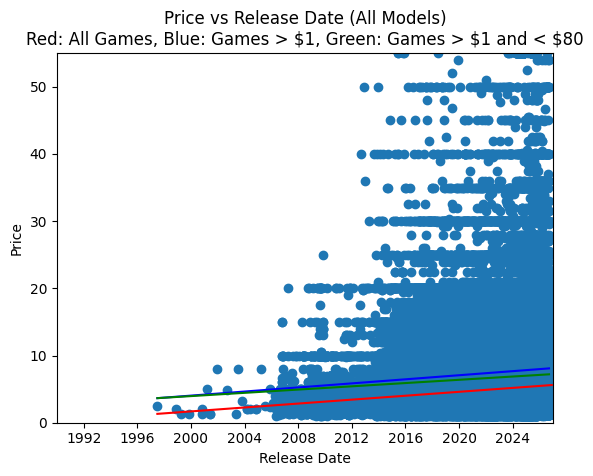

In [135]:
xfit = np.linspace(x.min(), x.max(), 250)
yfit = model.predict(xfit[:, np.newaxis])

xfit2 = np.linspace(x2.min(), x2.max(), 100)
yfit2 = model2.predict(xfit2[:, np.newaxis])

xfit3 = np.linspace(x3.min(), x3.max(), 100)
yfit3 = model3.predict(xfit3[:, np.newaxis])

plt.scatter(regression_data['release_date'], regression_data['price'],)
plt.plot(datefit, yfit, color='red')
plt.plot(datefit2, yfit2, color='blue')
plt.plot(datefit3, yfit3, color='green')
plt.xlabel('Release Date')
plt.ylabel('Price')
plt.title('Price vs Release Date (All Models)\n'
          'Red: All Games, Blue: Games > \$1, Green: Games > \$1 and < \$80')

plt.ylim(0, 55)
plt.xlim(pd.to_datetime('1990-01-01'), pd.to_datetime('2027-01-01'))
plt.show()

The three models plotted together show that the linear regression model is not a good fit for the data, regardless of how it is filtered. The R² values indicate that the models explain very little of the variation in game price. Although the models do show an upward trend in price over time, the very low R² values suggest that the release date is not a strong predictor for the price of the game.

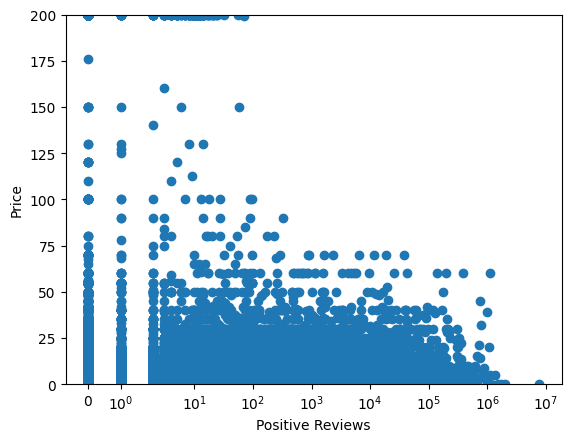

In [116]:
plt.scatter(plot_data['positive'], plot_data['price'])

plt.xscale('symlog')
plt.xlabel('Positive Reviews')
plt.ylabel('Price')
plt.ylim(0, 200)

plt.show()

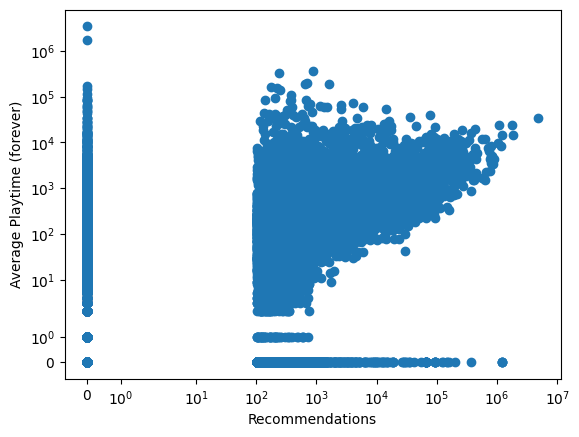

In [117]:
plt.scatter(plot_data['recommendations'], plot_data['average_playtime_forever'])

plt.xscale('symlog')
plt.yscale('symlog')
plt.xlabel('Recommendations')
plt.ylabel('Average Playtime (forever)')
plt.show()

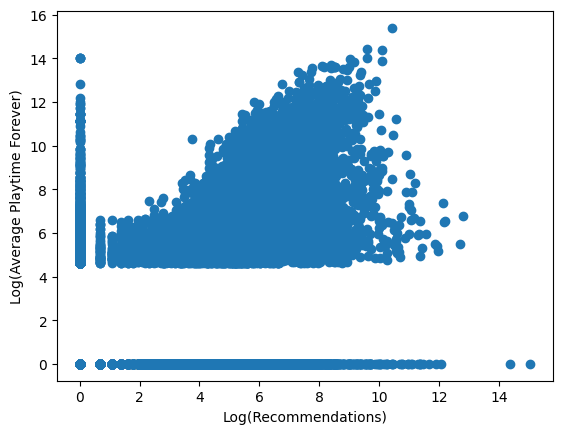

In [118]:
regression_data = plot_data[
    ['recommendations', 'average_playtime_forever']
].dropna().copy()

regression_data['log_recommendations'] = np.log1p(regression_data['recommendations'])

regression_data['log_avg_playtime_forever'] = np.log1p(regression_data['average_playtime_forever'])

x = regression_data['log_avg_playtime_forever'].to_numpy()
y = regression_data['log_recommendations'].to_numpy()

plt.scatter(x, y)
plt.xlabel('Log(Recommendations)')
plt.ylabel('Log(Average Playtime Forever)')
plt.show()

## Linear Regression Model attempting to predict average playtime from recommendations

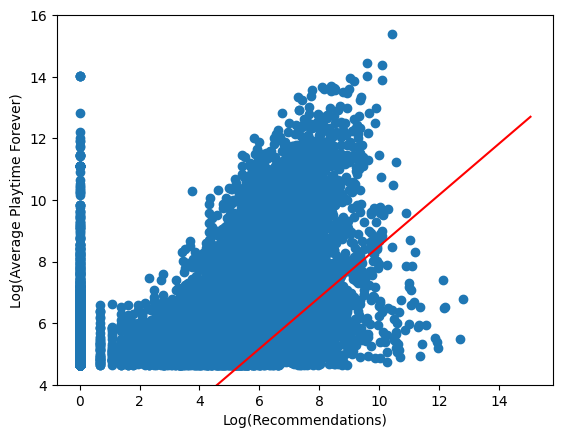

In [119]:
model = LinearRegression(fit_intercept=True)
model.fit(x[:, np.newaxis], y)

xfit = np.linspace(x.min(), x.max(), 100)
yfit = model.predict(xfit[:, np.newaxis])

plt.ylim(4, 16)
plt.scatter(x, y)
plt.plot(xfit, yfit, color='red')
plt.title('Average Playtime vs Recommendations')
plt.xlabel('Log(Recommendations)')
plt.ylabel('Log(Average Playtime Forever)')
plt.show()

As can be seen from the plot, the linear regression model does not fit the data well, indicating that a linear relationship is not appropriate for predicting average playtime from recommendations. The plotted data points show a bell-shaped distribution, suggesting that a non-linear model may be more suitable for this task.

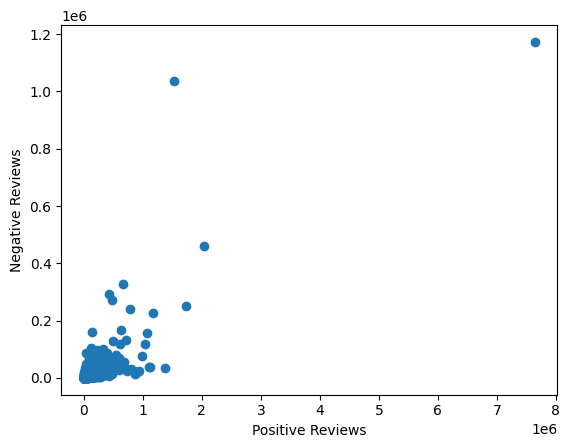

In [136]:
plt.scatter(plot_data['positive'], plot_data['negative'])

plt.xlabel('Positive Reviews')
plt.ylabel('Negative Reviews')

plt.show()

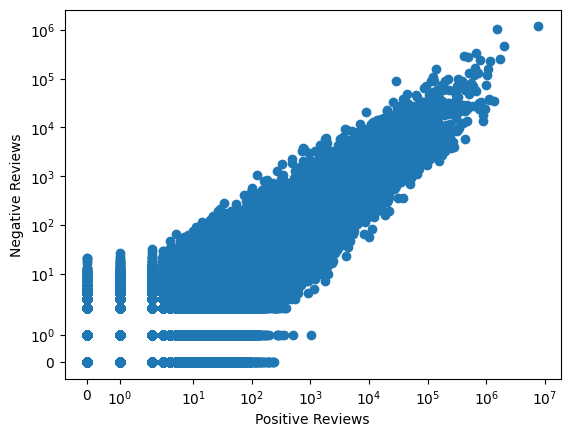

In [137]:
plt.scatter(plot_data['positive'], plot_data['negative'])

plt.xscale('symlog')
plt.yscale('symlog')
plt.xlabel('Positive Reviews')
plt.ylabel('Negative Reviews')

plt.show()

## Linear Regression Model attempting to predict negative reviews from positive reviews

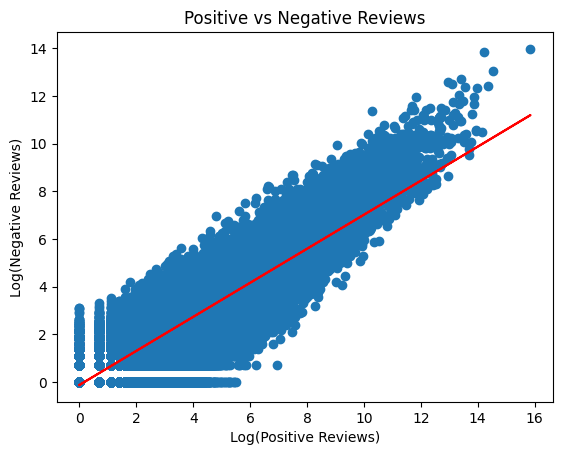

R²:  0.840511554518818


In [138]:
regression_data = plot_data[
    ['positive', 'negative']
].dropna().copy()

regression_data['log_positive'] = np.log1p(regression_data['positive'])
regression_data['log_negative'] = np.log1p(regression_data['negative'])

x = regression_data['log_positive'].to_numpy()
y = regression_data['log_negative'].to_numpy()

model = LinearRegression(fit_intercept=True)
model.fit(x[:, np.newaxis], y)

yfit = model.predict(x[:, np.newaxis])

plt.scatter(x, y)
plt.plot(x, yfit, color='red')

plt.title('Positive vs Negative Reviews')
plt.xlabel('Log(Positive Reviews)')
plt.ylabel('Log(Negative Reviews)')
plt.show()
print("R²: ", model.score(x[:, np.newaxis], y))

As can be seen from the plot and the R² value, the linear regression model fits the data well, indicating that a linear relationship is appropriate for predicting negative reviews from positive reviews.